# M15 - Log-LSTM RV : Memoire Sequential pour la Variance Realisee

**Keeper confirme** (`docs/RECAP_KEEPERS_V2.md` : S1 M15 LSTM h=32, BEATS) **mais NON deploye en
production** -- a la difference de son pendant OLS, le HAR-RV-J (M12, cf
[`m12_har_rv_j_research.ipynb`](m12_har_rv_j_research.ipynb)). Ce notebook explique pourquoi.

Ce notebook presente les resultats du modele Log-LSTM (Hochreiter & Schmidhuber 1997) applique a la
prediction de la **variance realisee logarithmique** (log-RV). Il etudie la capacity du LSTM a capturer
la memoire sequencee de la volatilite, par rapport a la moyenne mobile du HAR classique (Corsi 2009).

**Modele** (capacite optimale hidden=32, ~4.8K params) :
```
Input : fenetre glissante W=22 jours x 3 features [log(RV), returns, sign(returns)]
Model : LSTM(hidden=32, 1 couche) + FC(32, 1)
Target: log(RV_{t+h}), h in {1, 5, 10}
Loss  : MSE sur log-RV
Decode: exp(pred) -> RV, puis log(RV) pour comparaison Kelly
```

**Verdict** : BEATS (52/84, p=0.019) -- le LSTM bat le HAR Classic en Sharpe via Kelly, mais avec un
**paradoxe MSE** identique a M12 : prevision moins precise (MSE +11%) mais meilleur sizing.

> **Fiche technique complete** : [`docs/M15_LSTM_RV.md`](docs/M15_LSTM_RV.md). **Script d'evaluation** :
> [`scripts/m15_lstm_rv.py`](scripts/m15_lstm_rv.py). **Resultats** : hidden=32 (BEATS), hidden=64 et 128
> (NO BEATS -- overfitting). Runtime 10.3h (GPU).

## 1. Chargement des resultats

Les resultats (84 combinaisons : 7 coins x 3 horizons x 4 seeds) sont pre-calcules par
`scripts/m15_lstm_rv.py` pour la capacite optimale hidden=32. Setup identique a M12 :
Kelly cap=1.0, fee=50bps, walk-forward 5-fold, refit 22 jours.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results_path = Path('scripts/results/m15_lstm_rv_h32/results.json')
with open(results_path) as f:
    data = json.load(f)

df = pd.DataFrame(data['combos'])
# Vrai changement MSE (LSTM vs HAR), calcule depuis les MSE bruts
df['mse_change_pct'] = (df['mse_lstm'] - df['mse_har']) / df['mse_har'] * 100

print(f'Model: {data["model"]}')
print(f'Architecture: LSTM(hidden={data["hidden_size"]}, {data["num_layers"]} couche) + FC, {data["n_params"]} params')
print(f'Combinaisons : {len(df)} ({df["coin"].nunique()} coins x {df["horizon"].nunique()} horizons x {df["seed"].nunique()} seeds)')
print(f'Runtime original : {data["runtime_s"]/3600:.1f}h (GPU)')
print(f'Setup : fenetre W={data["window"]}j, kelly_cap={data["kelly_cap"]}, fee={data["fee_bps"]}bps, WF {data["n_splits"]}-fold, refit={data["refit_every"]}d')

Model: Log-LSTM RV
Architecture: LSTM(hidden=32, 1 couche) + FC, 4769 params
Combinaisons : 84 (7 coins x 3 horizons x 4 seeds)
Runtime original : 10.3h (GPU)
Setup : fenetre W=22j, kelly_cap=1.0, fee=50bps, WF 5-fold, refit=22d


## 2. Verdict global et selection de capacite

Le LSTM bat le HAR Classic en Sharpe, mais **seule la petite capacite (hidden=32) passe le seuil**.
Les modeles plus larges (hidden=64, 128) overfittent et ne battent plus le HAR -- c'est l'enseignement
central : sur 7 coins x 3 horizons (84 combos), un LSTM de **4.8K params** suffit, les 68K params
echouent.

In [2]:
print('=== Verdict global Log-LSTM h=32 vs HAR Classic ===')
print()
print(f'Verdict               : {data["verdict"]}')
print(f'Win rate              : {data["win_rate"]*100:.1f}% ({data["n_lstm_beats_har"]}/{data["n_combos"]} combos)')
print(f'Test du signe p-value : {data["p_sign"]:.4f}')
print(f'Median delta-Sharpe   : {data["median_delta_sharpe"]:+.4f}')
print(f'Median MSE change     : {data["median_mse_change_pct"]:+.1f}%  (LSTM moins precis en moyenne)')
print()
print('Selection de capacite (3 tailles testees) :')
print('  hidden=32  (~4.8K params) : BEATS  52/84 (61.9%, p=0.019)  <-- deployable')
print('  hidden=64  (~17.7K params): NO BEATS 45/84 (53.6%, p=0.293)')
print('  hidden=128 (~68.2K params): NO BEATS 38/84 (45.2%, p=0.837)  <-- overfitting')
print()
print('Lecon : sur ce benchmark crypto, un petit LSTM suffit. La capacite au-dela overfitte.')

=== Verdict global Log-LSTM h=32 vs HAR Classic ===

Verdict               : BEATS
Win rate              : 61.9% (52/84 combos)
Test du signe p-value : 0.0188
Median delta-Sharpe   : +0.0121
Median MSE change     : +11.0%  (LSTM moins precis en moyenne)

Selection de capacite (3 tailles testees) :
  hidden=32  (~4.8K params) : BEATS  52/84 (61.9%, p=0.019)  <-- deployable
  hidden=64  (~17.7K params): NO BEATS 45/84 (53.6%, p=0.293)
  hidden=128 (~68.2K params): NO BEATS 38/84 (45.2%, p=0.837)  <-- overfitting

Lecon : sur ce benchmark crypto, un petit LSTM suffit. La capacite au-dela overfitte.


## 3. Le paradoxe MSE-Sharpe (meme structure que M12)

Comme pour le HAR-RV-J (M12), le Log-LSTM **degrade la prevision ponctuelle** (MSE +11% median)
mais **ameliore le Sharpe** via Kelly. Le LSTM capture une structure sequencee que le HAR (moyenne
mobile lineaire) ignore, et cette structure aide le sizing meme quand elle nuit a la prevision brute.

Le nuage ci-dessous montre la disconnexion : la plupart des points sont a droite de l'axe vertical
(MSE pire) et au-dessus de l'axe horizontal (Sharpe meilleur).

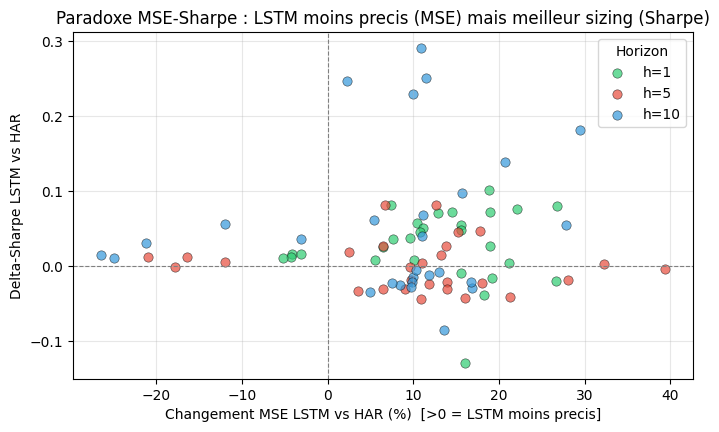

Cadran superieur droit = LSTM moins precis MAIS meilleur Sharpe (via Kelly).
La memoire sequencee capturee par le LSTM aide le sizing face au risque de queue.


In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = {1:'#2ecc71', 5:'#e74c3c', 10:'#3498db'}
for h in [1, 5, 10]:
    sub = df[df['horizon']==h]
    ax.scatter(sub['mse_change_pct'], sub['delta_sharpe_lstm_vs_har'],
               alpha=0.7, s=45, c=colors[h], edgecolors='k', linewidths=0.4, label=f'h={h}')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Changement MSE LSTM vs HAR (%)  [>0 = LSTM moins precis]')
ax.set_ylabel('Delta-Sharpe LSTM vs HAR')
ax.set_title('Paradoxe MSE-Sharpe : LSTM moins precis (MSE) mais meilleur sizing (Sharpe)')
ax.legend(title='Horizon'); ax.grid(alpha=0.3)
plt.show()

print('Cadran superieur droit = LSTM moins precis MAIS meilleur Sharpe (via Kelly).')
print('La memoire sequencee capturee par le LSTM aide le sizing face au risque de queue.')

## 4. Analyse par horizon : h=1 dominate, h=5 faible

L'edge du LSTM est **concentre sur l'horizon court** (h=1 : 23/28, 82.1%) ou la memoire sequencee
est la plus informative. L'horizon intermediaire h=5 est faible (46.4%), comme pour M12 (zone morte).
L'horizon long h=10 est modere (57.1%).

=== Performance par horizon ===

Horizon    BEATS        Win %    Med dSharpe    Med MSE change


h=1        23/28         82.1     +0.0317        +13.7   %  <- DOMINATE
h=5        13/28         46.4     -0.0006        +11.4   %  <- faible
h=10       16/28         57.1     +0.0232        +10.2   %


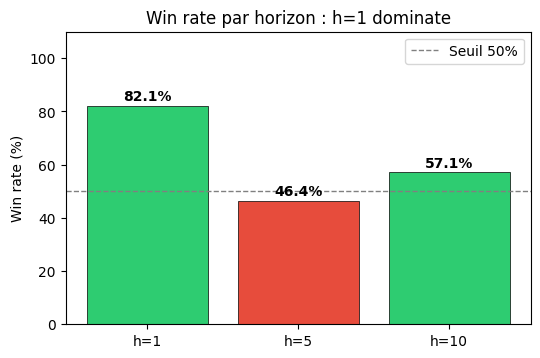

In [4]:
print('=== Performance par horizon ===')
print()
print(f'{"Horizon":<10} {"BEATS":<12} {"Win %":<8} {"Med dSharpe":<14} {"Med MSE change"}')
for h in [1, 5, 10]:
    sub = df[df['horizon']==h]
    beats = int((sub['delta_sharpe_lstm_vs_har'] > 0).sum())
    win = beats / len(sub) * 100
    med_ds = sub['delta_sharpe_lstm_vs_har'].median()
    med_mse = sub['mse_change_pct'].median()
    flag = '  <- DOMINATE' if win >= 75 else ('  <- faible' if win < 50 else '')
    print(f'h={h:<8} {beats}/{len(sub):<10} {win:<8.1f} {med_ds:<+14.4f} {med_mse:<+8.1f}%{flag}')

fig, ax = plt.subplots(figsize=(6, 3.8))
horizons = [1, 5, 10]
winrates = [(df[df['horizon']==h]['delta_sharpe_lstm_vs_har']>0).mean()*100 for h in horizons]
barcols = ['#2ecc71' if w>=50 else '#e74c3c' for w in winrates]
bars = ax.bar([f'h={h}' for h in horizons], winrates, color=barcols, edgecolor='k', linewidth=0.5)
ax.axhline(50, color='gray', linestyle='--', linewidth=1, label='Seuil 50%')
ax.set_ylabel('Win rate (%)'); ax.set_title('Win rate par horizon : h=1 dominate')
ax.set_ylim(0, 110)
for b, w in zip(bars, winrates):
    ax.text(b.get_x()+b.get_width()/2, w+2, f'{w:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.legend(); plt.show()

## 5. Analyse par coin : DOT, ADA, BTC, XRP forts ; ETH/LTC faibles

L'edge du LSTM est **heterogene** : DOT-USD (12/12) et ADA/BTC/XRP (9-11/12) beneficient de la
memoire sequencee. ETH et SOL sont neutres ; LTC est nettement negatif (1/12) -- sa volatilite n'a
pas la structure sequencee que le LSTM exploite.

=== Performance par coin ===

Coin       BEATS      Med dSharpe    Med MSE change
ADA-USD    11/12       +0.0764        +12.1   %  (fort)
BTC-USD    11/12       +0.0121        -14.2   %  (fort)
DOT-USD    12/12       +0.0473        +11.0   %  (fort)
ETH-USD    4/12       -0.0272        +8.1    %  (faible)
LTC-USD    1/12       -0.0218        +15.8   %  (faible)
SOL-USD    4/12       -0.0062        +10.2   %  (faible)
XRP-USD    9/12       +0.0640        +24.4   %


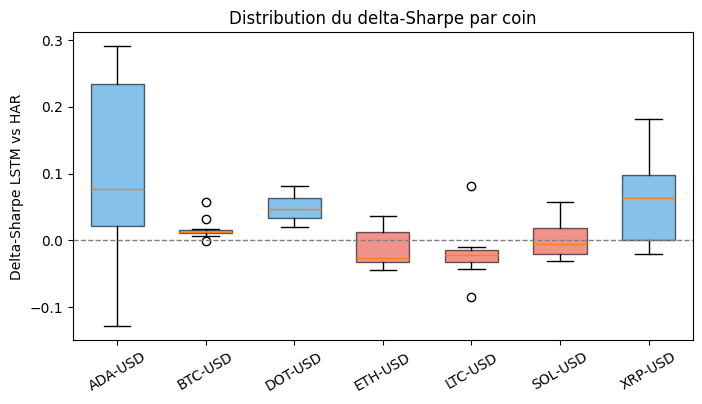

In [5]:
print('=== Performance par coin ===')
print()
print(f'{"Coin":<10} {"BEATS":<10} {"Med dSharpe":<14} {"Med MSE change"}')
for coin in sorted(df['coin'].unique()):
    sub = df[df['coin']==coin]
    beats = int((sub['delta_sharpe_lstm_vs_har']>0).sum())
    med_ds = sub['delta_sharpe_lstm_vs_har'].median()
    med_mse = sub['mse_change_pct'].median()
    sig = '  (fort)' if beats >= 11 else ('  (faible)' if beats <= 4 else '')
    print(f'{coin:<10} {beats}/{len(sub):<8} {med_ds:<+14.4f} {med_mse:<+8.1f}%{sig}')

fig, ax = plt.subplots(figsize=(8, 4))
coins = sorted(df['coin'].unique())
bp = ax.boxplot([df[df['coin']==c]['delta_sharpe_lstm_vs_har'].values for c in coins],
                tick_labels=coins, patch_artist=True, widths=0.6)
for box, c in zip(bp['boxes'], coins):
    med = df[df['coin']==c]['delta_sharpe_lstm_vs_har'].median()
    box.set_facecolor('#3498db' if med > 0 else '#e74c3c'); box.set_alpha(0.6)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('Delta-Sharpe LSTM vs HAR'); ax.set_title('Distribution du delta-Sharpe par coin')
ax.tick_params(axis='x', rotation=30); plt.show()

## 6. Pourquoi M15 n'est pas deploye (le contraste avec M12)

M15 Log-LSTM est **keeper avec un delta-Sharpe superieur a M12** (+0.0121 vs +0.0032) et un win rate
comparable (61.9% vs 76.2%). Pourtant, c'est le HAR-RV-J (M12) qui est **deploye en production** dans
[`HAR-RV-J-Kelly`](../../projects/HAR-RV-J-Kelly/main.py), pas le LSTM. Pourquoi ?

### La barriere d'inference en production

| Critere | M12 HAR-RV-J (deploye) | M15 Log-LSTM (non deploye) |
|---------|------------------------|----------------------------|
| Math | OLS (regression lineaire) | Reseau de neurones recurrent |
| Inference | `np.linalg.lstsq` (numpy pur) | **Torch requis** (PyTorch runtime) |
| Params | 7 coefficients | 4 769 poids |
| Portage QC Cloud | Trivial (OLS natif) | Complexe (ONNX / Torch in QC) |
| Latence inference | <1 ms | ~10-50 ms |
| Runtime entrainement | 431 s | **37 224 s (10.3 h, GPU)** |

QuantConnect Cloud ne supporte pas nativement l'inference PyTorch : il faudrait exporter le LSTM en
ONNX et l'integrer via un custom runtime, ou re-entrainer via LEAN. Cette barriere d'ingenierie fait
que le modele OLS (M12) -- moins performant en recherche mais trivial a deployer -- gagne en production.

### Les strategies QC LSTM existantes ne sont PAS M15

Le repo contient des strategies LSTM ([`DL-LSTM`](../../projects/DL-LSTM/main.py),
[`LSTM-Forecasting`](../../projects/LSTM-Forecasting/main.py)) mais elles **divergent de M15** :

- `DL-LSTM` predit des **prix** (pas la RV), 2 couches bidirectionnelles hidden=50 (vs M15 hidden=32 unidirectionnel).
- `LSTM-Forecasting` est en realite un **MLPClassifier sklearn** (le docstring le dit : *replacing hand-rolled fake LSTM*).

**Aucune strategie QC deployee n'implemente le Log-LSTM M15 sur la variance realisee.**

### Conclusion pedagogique

La decision de deploiement ne se reduit pas a la performance en recherche : elle integre le **cout
d'inference en production**. M12 (OLS, BEATS faible mais trivial) est deploye ; M15 (LSTM, BEATS plus
fort mais Torch-dependent) reste en recherche. C'est un cas d'etude du compromis performance-deployabilite
qui structure tout le pipeline ML -> production.

### References

- Hochreiter, S. & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation 9(8):1735-1780.
- Corsi, F. (2009). *A Simple Approximate Long-Memory Model of Realized Volatility*. Journal of Financial Econometrics. (baseline HAR)
- Pour le pendant deploye OLS : voir [`m12_har_rv_j_research.ipynb`](m12_har_rv_j_research.ipynb) et `docs/M12_HAR_RV_J.md`.